In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(16,8)
plt.style.use('seaborn-v0_8-colorblind')

In [2]:
data=pd.read_csv('movie_metadata.csv')

In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)

In [46]:
n=5
print(f'There are {len(data.columns)} columns present\n{data.shape[0]} rows')
for index in range(0,len(data.columns)-n):
    #display(data.iloc[:2,index:index+n])

SyntaxError: incomplete input (1829339321.py, line 4)

In [5]:
data.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

In [6]:
data = data.drop(columns=['color',
                          'director_facebook_likes',                          
                            'actor_1_facebook_likes',
                            'actor_3_facebook_likes', 
                            'actor_2_facebook_likes',
                            'cast_total_facebook_likes',
                            'facenumber_in_poster',
                            'content_rating', 
                            'movie_imdb_link', 
                            'country',
                            'aspect_ratio',
                            'plot_keywords',])

In [7]:
data.columns

Index(['director_name', 'num_critic_for_reviews', 'duration', 'actor_2_name',
       'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users',
       'actor_3_name', 'num_user_for_reviews', 'language', 'budget',
       'title_year', 'imdb_score', 'movie_facebook_likes'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   director_name           4939 non-null   object 
 1   num_critic_for_reviews  4993 non-null   float64
 2   duration                5028 non-null   float64
 3   actor_2_name            5030 non-null   object 
 4   gross                   4159 non-null   float64
 5   genres                  5043 non-null   object 
 6   actor_1_name            5036 non-null   object 
 7   movie_title             5043 non-null   object 
 8   num_voted_users         5043 non-null   int64  
 9   actor_3_name            5020 non-null   object 
 10  num_user_for_reviews    5022 non-null   float64
 11  language                5029 non-null   object 
 12  budget                  4551 non-null   float64
 13  title_year              4935 non-null   float64
 14  imdb_score              5043 non-null   

In [9]:
data.isna().sum()

director_name             104
num_critic_for_reviews     50
duration                   15
actor_2_name               13
gross                     884
genres                      0
actor_1_name                7
movie_title                 0
num_voted_users             0
actor_3_name               23
num_user_for_reviews       21
language                   14
budget                    492
title_year                108
imdb_score                  0
movie_facebook_likes        0
dtype: int64

In [10]:
data.shape

(5043, 16)

In [11]:
data=data.loc[~(data['budget'].isna())&~(data['gross'].isna())]

In [12]:
data.isna().sum()

director_name              0
num_critic_for_reviews     1
duration                   1
actor_2_name               5
gross                      0
genres                     0
actor_1_name               3
movie_title                0
num_voted_users            0
actor_3_name              10
num_user_for_reviews       0
language                   4
budget                     0
title_year                 0
imdb_score                 0
movie_facebook_likes       0
dtype: int64

In [13]:
data=data.loc[data.isna().sum(axis=1)<=2]
data.isna().sum()

director_name             0
num_critic_for_reviews    1
duration                  1
actor_2_name              2
gross                     0
genres                    0
actor_1_name              0
movie_title               0
num_voted_users           0
actor_3_name              7
num_user_for_reviews      0
language                  4
budget                    0
title_year                0
imdb_score                0
movie_facebook_likes      0
dtype: int64

In [14]:
data['num_critic_for_reviews'].fillna(data['num_critic_for_reviews'].mean(),inplace=True)
data['duration'].fillna(data['duration'].mean(),inplace=True)
data['language'].fillna(data['language'].mode()[0],inplace=True)
data['actor_2_name'].fillna('unknown',inplace=True)
data['actor_3_name'].fillna('unknown',inplace=True)
data['actor_3_name'].fillna('unknown',inplace=True)

In [15]:
data.isna().sum()

director_name             0
num_critic_for_reviews    0
duration                  0
actor_2_name              0
gross                     0
genres                    0
actor_1_name              0
movie_title               0
num_voted_users           0
actor_3_name              0
num_user_for_reviews      0
language                  0
budget                    0
title_year                0
imdb_score                0
movie_facebook_likes      0
dtype: int64

In [16]:
data['gross']=data['gross']/1_000_000
data['budget']=data['budget']/1_000_000
data['mill_profit']=data['gross']-data['budget']

In [17]:
pre_remove=data.shape[0]
data.drop_duplicates(keep='first',inplace=True,subset=None)
post_remove=data.shape[0]
total_removed=pre_remove-post_remove
print(total_removed,' rows removed.')

35  rows removed.


In [18]:
n=10
data[['mill_profit','movie_title']].sort_values(by="mill_profit",ascending=False).head(n).reset_index(drop=True)

,mill_profit,movie_title
0,523.505847,Avatar
1,502.177271,Jurassic World
2,458.672302,Titanic
3,449.935665,Star Wars: Episode IV - A New Hope
4,424.449459,E.T. the Extra-Terrestrial
5,403.279547,The Avengers
6,377.783777,The Lion King
7,359.544677,Star Wars: Episode I - The Phantom Menace
8,348.316061,The Dark Knight
9,329.999255,The Hunger Games


In [44]:
data['language'].value_counts()[:5]

language
English     3674
French        37
Spanish       26
Mandarin      14
German        13
Name: count, dtype: int64

In [20]:
data['english']='English'
data['language']=data['language'].str.strip().str.title()
mask=data['language']!='English'
data.loc[mask,'english']='Foreign'
data['english'].value_counts()

english
English    3674
Foreign     179
Name: count, dtype: int64

In [45]:
data['duration'].value_counts().iloc[:5]

duration
101.0    113
100.0    109
98.0     105
95.0      97
99.0      97
Name: count, dtype: int64

In [22]:
data['length']='short'
mask=data['duration']>120
data.loc[mask,'length']='long'
data['length'].value_counts()

length
short    2936
long      917
Name: count, dtype: int64

In [74]:
data['genres'].value_counts()[:5]

genres
[Drama]                     153
[Comedy, Drama, Romance]    151
[Comedy, Drama]             147
[Comedy]                    145
[Comedy, Romance]           135
Name: count, dtype: int64

In [24]:
data['genres']=data['genres'].str.split('|')
data['genres'][0:5]

0    [Action, Adventure, Fantasy, Sci-Fi]
1            [Action, Adventure, Fantasy]
2           [Action, Adventure, Thriller]
3                      [Action, Thriller]
5             [Action, Adventure, Sci-Fi]
Name: genres, dtype: object

In [27]:
genres=['genre_1','genre_2','genre_3','genre_4']
for i in genres:
    data[i]=data['genres'].apply(lambda x:x[0])
    index=int(i[-1:])-1
    mask=data['genres'].apply(len)>index
    data.loc[mask,i]=data.loc[mask,'genres'].apply(lambda x: x[index])


In [102]:
data.sample()

,director_name,num_critic_for_reviews,duration,actor_2_name,gross,genres,actor_1_name,movie_title,num_voted_users,actor_3_name,...,movie_facebook_likes,mill_profit,english,length,genre_1,genre_2,genre_3,genre_4,popularity,social_media_popularity
1314,Danny Boyle,308.0,107.0,Benedict Wong,3.675072,"[Adventure, Sci-Fi, Thriller]",Chris Evans,Sunshine,190132,Troy Garity,...,15000,-22.324928,English,short,Adventure,Sci-Fi,Thriller,Adventure,24.298908,0.000063


In [47]:
data['social_media_popularity']=(data['num_user_for_reviews']/data['num_voted_users'])*(data['movie_facebook_likes'])/1_000_000

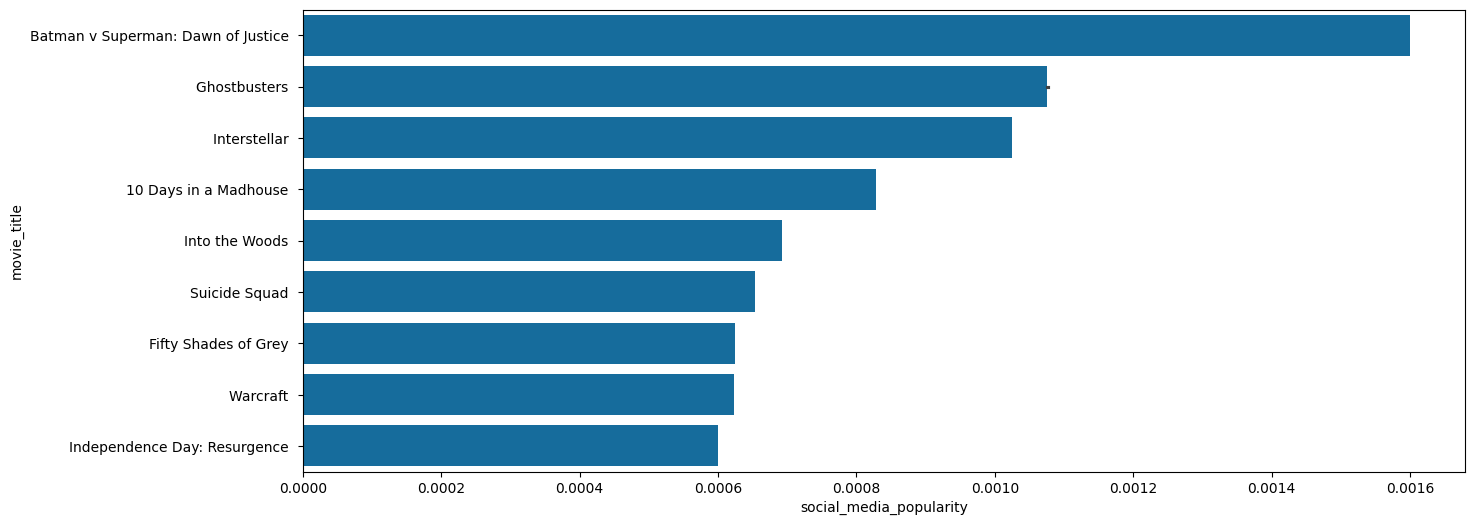

In [48]:
n=10
plot2=data[['social_media_popularity','movie_title']].sort_values(by='social_media_popularity',ascending=False).head(n).reset_index(drop=True)
x=plot2['social_media_popularity']
y=plot2['movie_title']
plt.figure(figsize=(15,6))
sns.barplot(x=x,y=y)
plt.show()

In [70]:
group1=data[['genre_1','gross']].groupby('genre_1',as_index=False)['gross'].agg(['min','mean','max']).sort_values(by='mean',ascending=False).reset_index(drop=True)
display(group1.sort_values(by='mean',ascending=False).style.background_gradient(cmap='Wistia'))

,genre_1,min,mean,max
0,Family,2.119994,149.160478,434.949459
1,Musical,2.808000,92.084000,181.360000
2,Animation,0.071442,89.873480,368.049635
3,Adventure,0.004091,87.827145,436.471036
4,Action,0.000162,76.584686,760.505847
5,Mystery,0.016066,48.822296,217.536138
6,Fantasy,0.003478,40.483059,100.614858
7,Comedy,0.000703,37.611935,329.691196
8,Biography,0.012836,36.431983,255.950375
9,Horror,0.005725,34.737117,204.565000


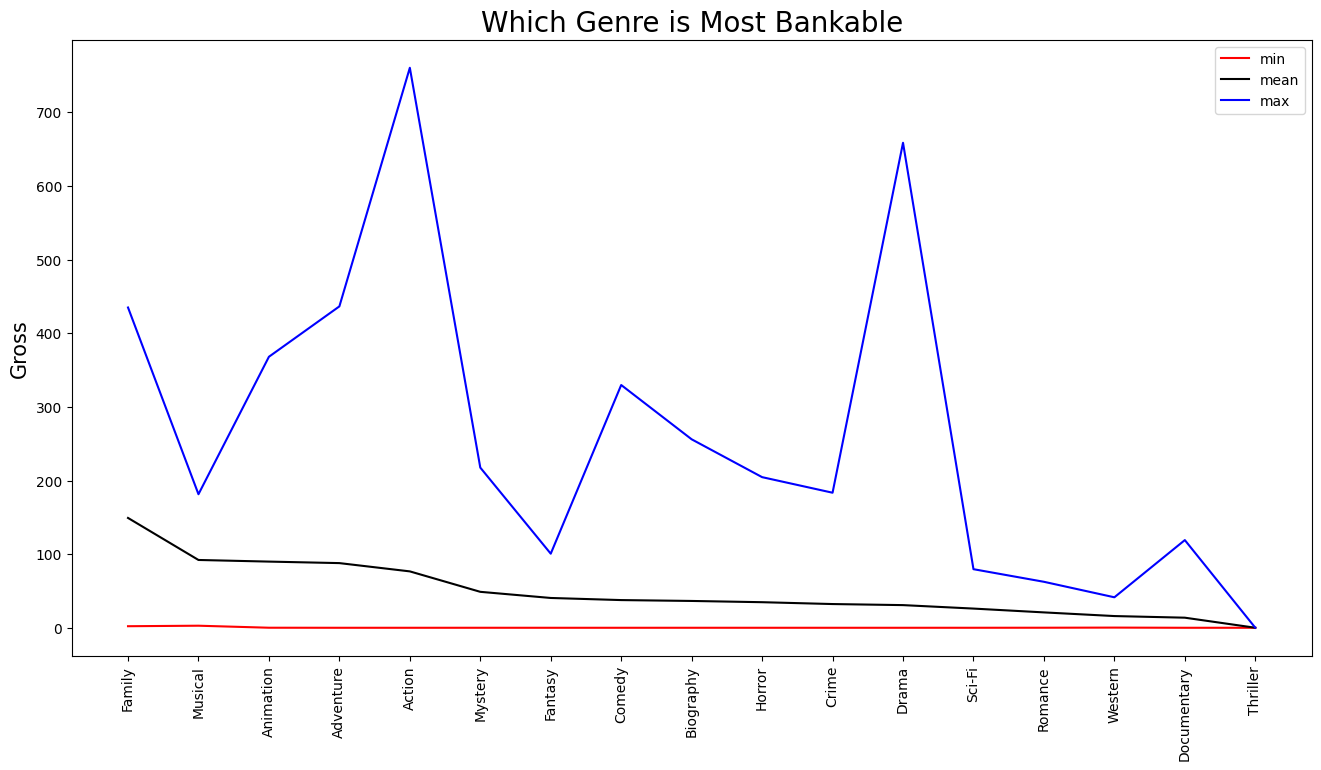

In [72]:
group1.plot(kind='line',color=['red','black','blue'])
plt.title('Which Genre is Most Bankable',fontsize=20)
plt.xticks(np.arange(len(group1['genre_1'])),list(group1['genre_1']),rotation=90)
plt.ylabel('Gross',fontsize=15)
plt.xlabel('')
plt.show()


In [82]:
print('Most Profitable by Genre')
display(data.loc[data.groupby(['genre_1'])['mill_profit'].idxmax()][['genre_1','movie_title','gross']].reset_index(drop=True).style.background_gradient(cmap='copper'))

Most Profitable by Genre


,genre_1,movie_title,gross
0,Action,Avatar,760.505847
1,Adventure,The Lion King,422.783777
2,Animation,Despicable Me 2,368.049635
3,Biography,The Blind Side,255.950375
4,Comedy,Forrest Gump,329.691196
5,Crime,The Godfather,134.821952
6,Documentary,Fahrenheit 9/11,119.078393
7,Drama,Titanic,658.672302
8,Family,E.T. the Extra-Terrestrial,434.949459
9,Fantasy,The Others,96.471845


In [85]:
data['title_year']=data['title_year'].astype(int)
data['title_year'][:5]

0    2009
1    2007
2    2015
3    2012
5    2012
Name: title_year, dtype: int32

In [96]:
n=10
print('Most Profitable Years in Box Office')
display(data[['title_year','english','mill_profit']]
        .groupby(['english','title_year']).agg('sum').sort_values(by='mill_profit',
        ascending=False).head(n).style.background_gradient(cmap='Greens'))

Most Profitable Years in Box Office


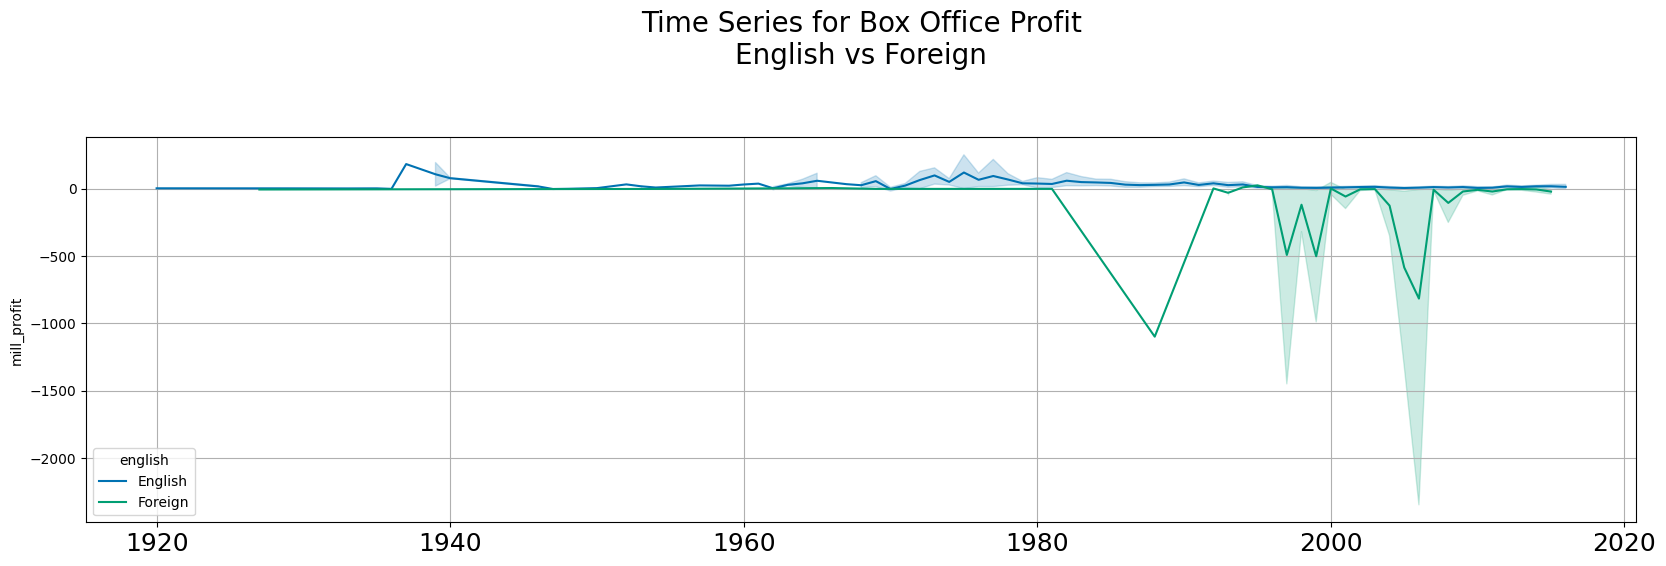

In [97]:
plt.figure(figsize=(20,5))
sns.lineplot(x=data['title_year'],y=data['mill_profit'],hue=data['english'])
plt.title(f"Time Series for Box Office Profit\nEnglish vs Foreign\n\n",fontsize=20)
plt.xticks(fontsize=18)
plt.xlabel('')
plt.grid()
plt.show()         

In [101]:
print("foreign movies with high losses")
display(data.loc[(data['mill_profit']<-2_000)
                 #&(data['english']=='Foreign')
                 ]
                 [['movie_title','english','mill_profit']]
                 .style.background_gradient(cmap='Reds'))

foreign movies with high losses


,movie_title,english,mill_profit
2323,Princess Mononoke,Foreign,-2397.701809
2334,Steamboy,Foreign,-2127.109510
2988,The Host,Foreign,-12213.298588
3005,Fateless,Foreign,-2499.804112
3859,Lady Vengeance,Foreign,-4199.788333


In [104]:
n=5
short=data.loc[data['length']=='short'][['movie_title','length','gross','mill_profit']].sort_values(by='mill_profit',ascending=False).head(n).reset_index(drop=True)
long=data.loc[data['length']=='long'][['movie_title','length','gross','mill_profit']].sort_values(by='mill_profit',ascending=False).head(n).reset_index(drop=True)
for i in [short,long]:
    display(i.style.background_gradient(cmap='spring'))

,movie_title,length,gross,mill_profit
0,E.T. the Extra-Terrestrial,short,434.949459,424.449459
1,The Lion King,short,422.783777,377.783777
2,Deadpool,short,363.024263,305.024263
3,Despicable Me 2,short,368.049635,292.049635
4,Finding Nemo,short,380.838870,286.838870


,movie_title,length,gross,mill_profit
0,Avatar,long,760.505847,523.505847
1,Jurassic World,long,652.177271,502.177271
2,Titanic,long,658.672302,458.672302
3,Star Wars: Episode IV - A New Hope,long,460.935665,449.935665
4,The Avengers,long,623.279547,403.279547


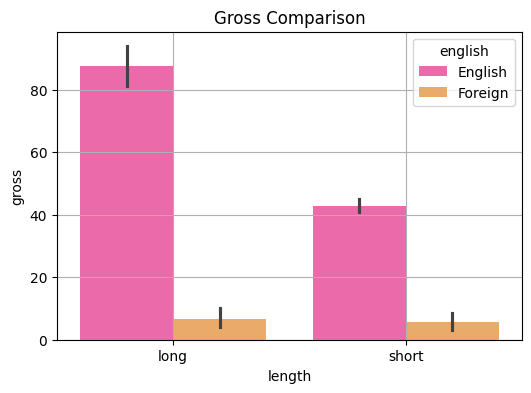

In [106]:
plt.figure(figsize=(6,4))
sns.barplot(x=data['length'],y=data['gross'],hue=data['english'],palette='spring')
plt.title('Gross Comparison')
plt.grid()
plt.show()

In [109]:
print(f"Average IMBB Score for Long Duration Movies is {round(data.loc[data['length']=='long']['imdb_score'].mean(),2)}")
print(f"Average IMBB Score for Short Duration Movies is {round(data.loc[data['length']=='short']['imdb_score'].mean(),2)}")

Average IMBB Score for Long Duration Movies is 7.06
Average IMBB Score for Short Duration Movies is 6.28


In [114]:
n=1
high_short=data.loc[data['length']=='short'][['movie_title','imdb_score']].sort_values(by='imdb_score',ascending=False).reset_index(drop=True)
high_long=data.loc[data['length']=='long'][['movie_title','imdb_score']].sort_values(by='imdb_score',ascending=False).reset_index(drop=True)
print(f"\nhighest rated short duration movie: \n{high_short.head(n)}".title())
print(f"\nhighest rated long duration movie: \n{high_long.head(n)}".title())


Highest Rated Short Duration Movie: 
           Movie_Title  Imdb_Score
0  The Usual Suspects          8.6

Highest Rated Long Duration Movie: 
                 Movie_Title  Imdb_Score
0  The Shawshank Redemption          9.3


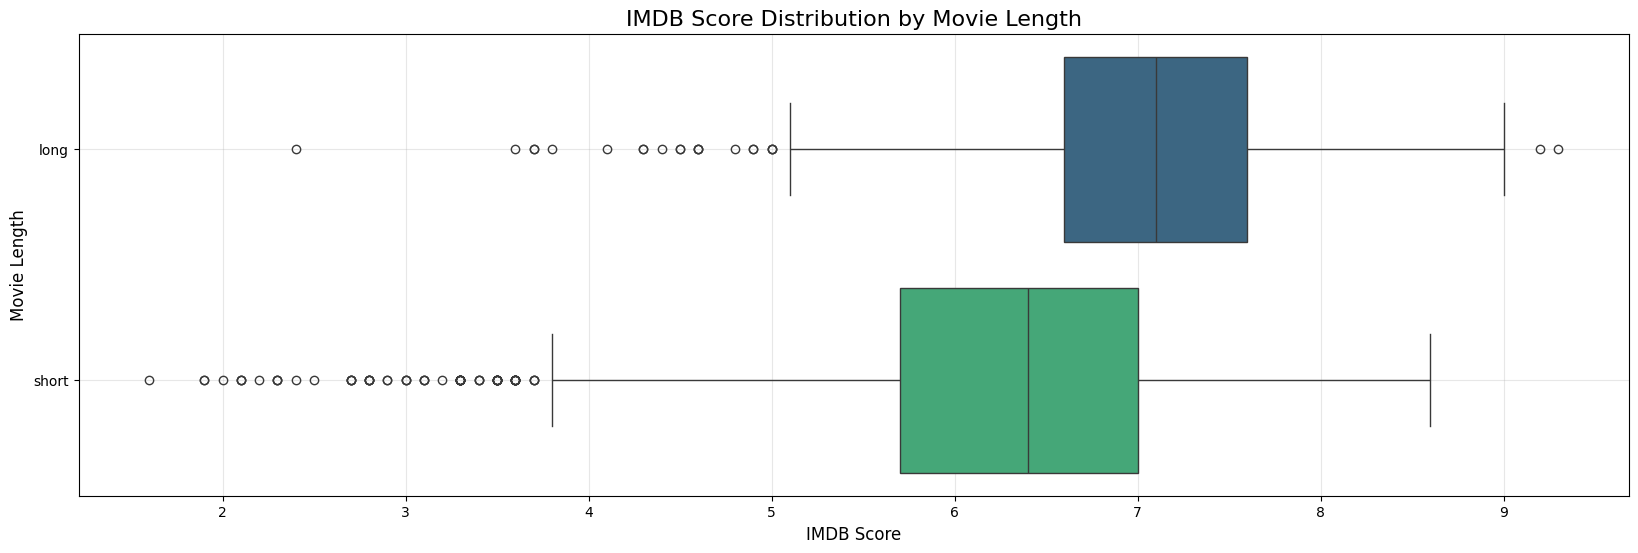

In [116]:
plt.figure(figsize=(20, 6))
sns.boxplot(x=data['imdb_score'], y=data['length'], palette='viridis')
plt.title('IMDB Score Distribution by Movie Length', fontsize=16)
plt.ylabel('Movie Length', fontsize=12)
plt.xlabel('IMDB Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [132]:
def query_actor(x):
    a=data.loc[data['actor_1_name']==x]
    b=data.loc[data['actor_2_name']==x]
    c=data.loc[data['actor_3_name']==x]
    x=pd.concat([a,b])
    y=pd.concat([x,c])
    y=y.sort_values(by='imdb_score',ascending=False).reset_index(drop=True)
    y=y[['movie_title',
         'budget',
         'gross',
         'title_year',
         'genre_1',
         'english',
         'imdb_score']]
    return y

In [133]:
query_actor('Meryl Streep')

,movie_title,budget,gross,title_year,genre_1,english,imdb_score
0,Fantastic Mr. Fox,40.0,20.999103,2009,Adventure,English,7.8
1,Adaptation.,19.0,22.245861,2002,Comedy,English,7.7
2,The Hours,25.0,41.597830,2002,Drama,English,7.6
3,Doubt,20.0,33.422556,2008,Drama,English,7.5
4,The Bridges of Madison County,35.0,70.960517,1995,Drama,English,7.5
5,August: Osage County,25.0,37.738400,2013,Drama,English,7.3
6,Out of Africa,31.0,87.100000,1985,Biography,English,7.2
7,Julie & Julia,40.0,94.125426,2009,Biography,English,7.0
8,One True Thing,30.0,23.209440,1998,Drama,English,7.0
9,The Devil Wears Prada,35.0,124.732962,2006,Comedy,English,6.8


In [146]:
def actor_report(x,n:int=5):
    a=data.loc[data['actor_1_name']==x]
    b=data.loc[data['actor_2_name']==x]
    c=data.loc[data['actor_3_name']==x]
    x=pd.concat([a,b])
    y=pd.concat([x,c])
    print(f"Time: {y['title_year'].min()} - {y['title_year'].max()}")
    print(F"Years Spanned: {y['title_year'].max()-y['title_year'].min()}")
    print(f"Max Gross: {round(y['gross'].max(),2)} Millions")
    print(f"Avg Gross: {round(y['gross'].mean(),2)} Millions")
    print(f"Min Gross: {round(y['gross'].min(),2)} Millions")
    print(f"Number of 100 Million Gross Movies: {y.loc[y['gross']>=100].shape[0]}")
    print(f"Avg IMDB Score: {round(y['imdb_score'].mean(),2)}")
    print(f"{n} Most Common Genres: {y['genre_1'].value_counts().head(n)}")

In [147]:
actor_report('Meryl Streep')

Time: 1985 - 2014
Years Spanned: 29
Max Gross: 143.7 Millions
Avg Gross: 55.23 Millions
Min Gross: 9.66 Millions
Number of 100 Million Gross Movies: 4
Avg IMDB Score: 6.81
5 Most Common Genres: genre_1
Drama        9
Comedy       7
Biography    3
Adventure    3
Action       1
Name: count, dtype: int64


In [149]:
def critically_acclaimed_actors(x): 
    a=data.loc[data['actor_1_name']==x]
    b=data.loc[data['actor_2_name']==x]
    c=data.loc[data['actor_3_name']==x]
    x=pd.concat([a,b])
    y=pd.concat([x,c])
    return y['num_critic_for_reviews'].sum().astype(int)

print('number of critic reviews for leonardo dicaprio'.title())
display(critically_acclaimed_actors('Leonardo DiCaprio'))
print('number of critic reviews for tom cruise'.title())
display(critically_acclaimed_actors('Tom Cruise'))
print('number of critic reviews for brad pitt'.title())
display(critically_acclaimed_actors('Brad Pitt'))

Number Of Critic Reviews For Leonardo Dicaprio


7014

Number Of Critic Reviews For Tom Cruise


6740

Number Of Critic Reviews For Brad Pitt


7814

In [158]:
pd.set_option('display.max_rows',1_000)
@interact
def show_movies_more_than(column='imdb_score',score=9.0):
    x=data.loc[data[column]>score][['title_year',
                                    'director_name',
                                    'actor_1_name',
                                    'actor_2_name',
                                    'actor_3_name',
                                    'mill_profit',
                                    'imdb_score']]
    x=x.sort_values(by='imdb_score',ascending=False)
    x=x.drop_duplicates(keep='first').reset_index(drop=True)
    return x

interactive(children=(Text(value='imdb_score', description='column'), FloatSlider(value=9.0, description='scor…

In [160]:
@interact
def articles_more_than(columns=['budget','gross'],x=1_000):
    return data.loc[data[columns]>x][['movie_title','length','mill_profit','imdb_score']].reset_index(drop=True)

interactive(children=(Dropdown(description='columns', options=('budget', 'gross'), value='budget'), IntSlider(…

In [174]:
def recomend_lang(x,foreign=False,n:int=5):
    x=x.title()
    if foreign:
        y=data.loc[data['language']==x][['english','movie_title','imdb_score']]
    else:
        y=data.loc[data['english']==x][['language','movie_title','imdb_score']]
    y=y.sort_values(by='imdb_score',ascending=False)
    return y.head(n).reset_index(drop=True)

In [176]:
recomend_lang('foreign',False,15)

,language,movie_title,imdb_score
0,Italian,"The Good, the Bad and the Ugly",8.9
1,Portuguese,City of God,8.7
2,Japanese,Seven Samurai,8.7
3,Japanese,Spirited Away,8.6
4,Persian,Children of Heaven,8.5
5,German,The Lives of Others,8.5
6,Persian,A Separation,8.4
7,Telugu,Baahubali: The Beginning,8.4
8,French,Amélie,8.4
9,Japanese,Princess Mononoke,8.4


In [181]:
def recomend_act(x,n:int=5):
    a=data.loc[data['actor_1_name']==x]
    b=data.loc[data['actor_2_name']==x]
    c=data.loc[data['actor_3_name']==x]
    x=pd.concat([a,b])
    y=pd.concat([x,c])
    y=y.sort_values(by='imdb_score',ascending=False).reset_index(drop=True)
    return y[['movie_title','imdb_score']].head(n)

In [182]:
recomend_act('Tom Cruise')

,movie_title,imdb_score
0,Rain Man,8.0
1,Edge of Tomorrow,7.9
2,Minority Report,7.7
3,The Last Samurai,7.7
4,Collateral,7.6


In [209]:
from mlxtend.preprocessing import TransactionEncoder

x=data['genres']
te=TransactionEncoder()
te.fit_transform(x)

gen_cols=['genre_1','genre_2','genre_3']
for col in gen_cols:
    data[i]=data[i].astype(str).str.strip().str.title()

for i in te.columns_:
    data[i]=0
    for col in gen_cols:
        mask=data[col]==i
        data.loc[mask,i]=1

X=data[['movie_title']+te.columns_]
X=X.set_index('movie_title')

def sim_genres(gen,n:int=5):
    gen=X[gen]
    similar=X.corrwith(gen)
    similar=similar.sort_values(ascending=False)
    similar=similar.iloc[1:]
    return similar.head(n)


In [210]:

for i in X.columns:
    print('gen: ',i)
    print('similar: ',sim_genres(i).index)

gen:  Action
similar:  Index(['Adventure', 'Sci-Fi', 'Crime', 'Thriller', 'Fantasy'], dtype='object')
gen:  Adventure
similar:  Index(['Action', 'Animation', 'Family', 'Sci-Fi', 'Fantasy'], dtype='object')
gen:  Animation
similar:  Index(['Adventure', 'Family', 'Comedy', 'Film-Noir', 'Short'], dtype='object')
gen:  Biography
similar:  Index(['History', 'Drama', 'Sport', 'Music', 'Documentary'], dtype='object')
gen:  Comedy
similar:  Index(['Romance', 'Animation', 'Family', 'Musical', 'Music'], dtype='object')
gen:  Crime
similar:  Index(['Thriller', 'Action', 'Mystery', 'Drama', 'Film-Noir'], dtype='object')
gen:  Documentary
similar:  Index(['Short', 'Music', 'Biography', 'War', 'Sport'], dtype='object')
gen:  Drama
similar:  Index(['Biography', 'History', 'Romance', 'War', 'Music'], dtype='object')
gen:  Family
similar:  Index(['Animation', 'Fantasy', 'Adventure', 'Comedy', 'Musical'], dtype='object')
gen:  Fantasy
similar:  Index(['Family', 'Horror', 'Adventure', 'Action', 'Film-Noi

In [208]:
movie_compare=X.T
movie_compare.sample(2)

movie_title,Avatar,Pirates of the Caribbean: At World's End,Spectre,The Dark Knight Rises,John Carter,Spider-Man 3,Tangled,Avengers: Age of Ultron,Harry Potter and the Half-Blood Prince,Batman v Superman: Dawn of Justice,...,Breaking Upwards,Pink Flamingos,Clean,The Circle,The Cure,Primer,Cavite,El Mariachi,Newlyweds,My Date with Drew
Adventure,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
War,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [211]:
def similar_movies(movie,n:int=5):
    movie=movie_compare[movie]
    similar=movie_compare.corrwith(movie)
    similar=similar.sort_values(ascending=False)
    similar=similar.iloc[1:]
    return similar.head(n)

In [214]:
for movie in movie_compare.columns[::1_000]:
    print(f'movie:',movie)
    print(f'similar: ',similar_movies(movie).index)

movie: Avatar 
similar:  Index(['Clash of the Titans ', 'Warriors of Virtue ', 'Mortal Kombat ',
       'Underworld: Rise of the Lycans ', 'Blade: Trinity '],
      dtype='object', name='movie_title')
movie: Insomnia 
similar:  Index(['Pi ', 'Brokedown Palace ', 'Mulholland Drive ', 'Disturbia ',
       'The Orphanage '],
      dtype='object', name='movie_title')
movie: The Descendants 
similar:  Index(['Winter Passing ', 'The Station Agent ', 'Bad Words ',
       'Our Brand Is Crisis ', 'UHF '],
      dtype='object', name='movie_title')
movie: Men with Brooms 
similar:  Index(['Home Fries ', 'Away We Go ', 'Next Stop Wonderland ',
       'Silver Linings Playbook ', 'Hope Springs '],
      dtype='object', name='movie_title')


In [232]:
titles=['A Separation'.title(),'Spirited Away'.title(),'City of God'.title(),"Pan's Labyrinth".title()]
data['movie_title']=data['movie_title'].str.strip().str.title()
data.loc[data['movie_title'].isin(titles)][['movie_title','gross']].sort_values(by='gross',ascending=False)        

,movie_title,gross
2551,Pan'S Labyrinth,37.623143
2373,Spirited Away,10.049886
4029,City Of God,7.563397
4659,A Separation,7.098492


In [233]:
data.to_csv('manipulated_data.csv',index=False)